In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot  as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [18]:
dataset = fetch_california_housing()

output = dataset.target
data = dataset.data
columns = dataset.feature_names
dataset.DESCR
df = pd.DataFrame(
    data=data,
    columns=columns
)
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [19]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [20]:
df["HouseVal"]=output

In [21]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


MedInc           0.688075
HouseAge         0.105623
AveRooms         0.151948
AveBedrms       -0.046701
Population      -0.024650
AveOccup        -0.023737
Latitude        -0.144160
Longitude       -0.045967
HouseVal         1.000000
roomperperson    0.209482
Name: HouseVal, dtype: float64

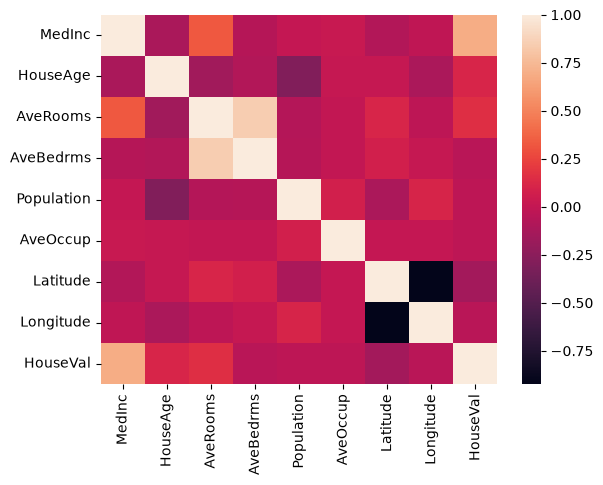

In [22]:
sns.heatmap(df.corr())


df["roomperperson"]=df["AveRooms"]/df["AveOccup"]
df.corr()["HouseVal"]

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

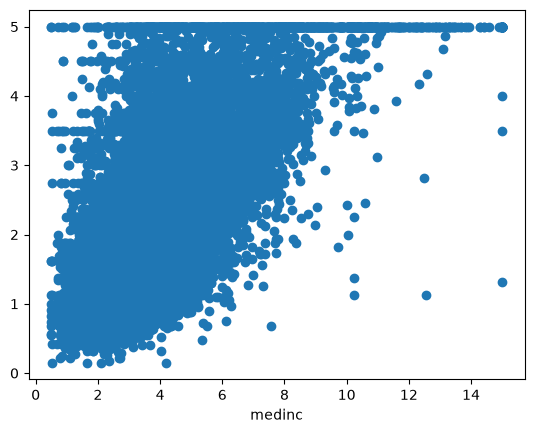

In [23]:
plt.scatter(df["MedInc"],df["HouseVal"])
plt.xlabel("medinc")
df["MedInc"].describe()

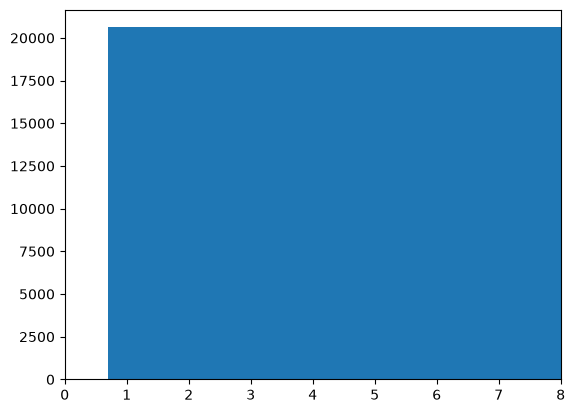

In [24]:
plt.hist(df["AveOccup"], bins=100)
plt.xlim(0, 8)
plt.show()

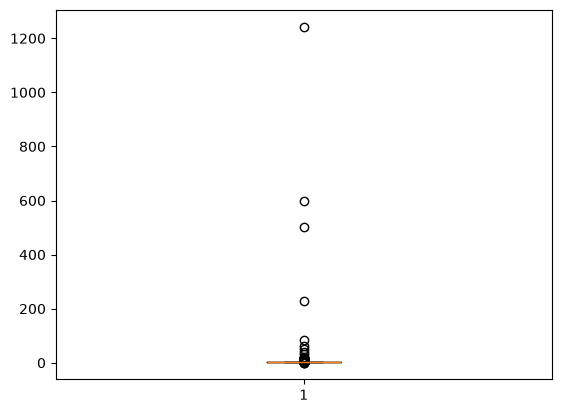

-0.02373741295613436
-0.2470439243188434


In [25]:
plt.boxplot(df["AveOccup"])
plt.show()
corr_original = df["AveOccup"].corr(df["HouseVal"])

corr_log = np.log1p(df["AveOccup"]).corr(df["HouseVal"])

print(corr_original)
print(corr_log)

In [26]:
df["HouseVal"].corr(df["Population"])

np.float64(-0.02464967888889488)

In [27]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseVal,roomperperson
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646


In [28]:
df=df.drop("HouseVal",axis=1)
output

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [29]:
X_train, X_test, y_train, y_test = train_test_split(df,output,test_size=0.2, random_state=42)

X_train=X_train.to_numpy()
X_test=X_test.to_numpy()
print(" Shape ", X_train, X_test, y_train.shape, y_test.shape, type(X_train))
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)
n=X_train.shape[1]
m=X_train.shape[0]
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std


 Shape  [[   3.2596       33.            5.0176565  ...   32.71
  -117.03          1.35913043]
 [   3.8125       49.            4.47354497 ...   33.77
  -118.16          2.5738204 ]
 [   4.1563        4.            5.64583333 ...   34.66
  -120.48          2.07322404]
 ...
 [   2.9344       36.            3.98671727 ...   34.03
  -118.38          1.19646925]
 [   5.7192       15.            6.39534884 ...   37.58
  -121.96          2.01181767]
 [   2.5755       52.            3.40257649 ...   37.77
  -122.42          1.61359297]] [[   1.6812       25.            4.19220056 ...   36.06
  -119.01          1.08117816]
 [   2.5313       30.            5.03938356 ...   35.14
  -119.46          1.88051118]
 [   3.4801       52.            3.97715472 ...   37.8
  -122.44          2.92366412]
 ...
 [   9.2298       25.            7.23767606 ...   37.31
  -122.05          2.59369085]
 [   2.785        36.            5.28902954 ...   36.77
  -119.76          2.04319478]
 [   3.5521       17.    

In [30]:
num_iter=20000
alpha=0.001
W=np.zeros((n,1))
b=np.zeros((1,1))
print(" ALL SHAPES")
print(X_train_norm.shape, X_test.shape, y_train.shape, y_test.shape, W.shape, b.shape)
loss_history=[]


 ALL SHAPES
(16512, 9) (4128, 9) (16512, 1) (4128, 1) (9, 1) (1, 1)


 final w and b  [[ 0.80454032]
 [ 0.15494893]
 [-0.4730251 ]
 [ 0.08360347]
 [ 0.04088068]
 [-0.0219472 ]
 [-0.70272351]
 [-0.64379373]
 [ 0.47020803]] [[2.07194693]]


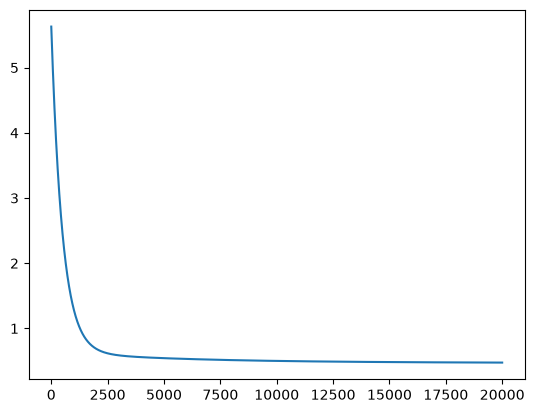

In [31]:
def compute_gradient(X_train, y_train, y_hat):
    error = y_hat - y_train
    prod = X_train.T @ error
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    dW=(1/m)*prod
    db=(1/m)*(np.sum(error))
    return dW, db
    
for _ in range(num_iter):
    y_hat = X_train_norm @ W + b
    dW, db = compute_gradient(X_train_norm, y_train, y_hat)
    W= W-(alpha*dW)
    b=b-(alpha*db)

plt.plot(loss_history)
print(" final w and b ", W, b)

In [32]:
y_pred_train = X_test_norm @ W + b

mse_train = np.mean((y_pred_train - y_test) ** 2)
rmse_train = np.sqrt(mse_train)
print(rmse_train)
print(y_train[0])
print(y_pred_train.shape, y_train.shape)
print(y_pred_train[0], y_train[0])

0.6916144320520765
[1.03]
(4128, 1) (16512, 1)
[0.63102788] [1.03]


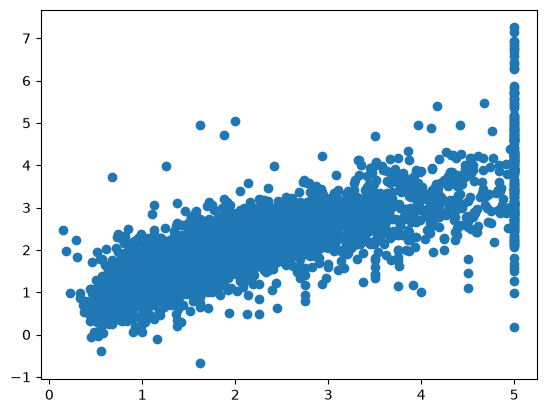

In [34]:
plt.scatter(y_test, y_pred_train)

In [ ]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_norm,y_train)
y_pred_model = model.predict(X_test_norm)

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_sklearn = np.sqrt(
    mean_squared_error(y_test, y_pred_model)
)

print("rmse sklearn",rmse_sklearn)
print("rmse train",rmse_train)
# print("rmse base",rmse_base)

rmse sklearn 0.6873076952059135
rmse train 0.6916144320520765


In [38]:
from sklearn.metrics import r2_score

y_pred = X_test_norm @ W + b

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6349761558678957
